In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Download MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor(),           # pixel values 0-255 → 0.0-1.0
    transforms.Normalize((0.1307,), (0.3081,))  # normalize with dataset mean/std
])

train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples:     {len(test_dataset)}")
print(f"Input shape:      {train_dataset[0][0].shape}")

Training samples: 60000
Test samples:     10000
Input shape:      torch.Size([1, 28, 28])


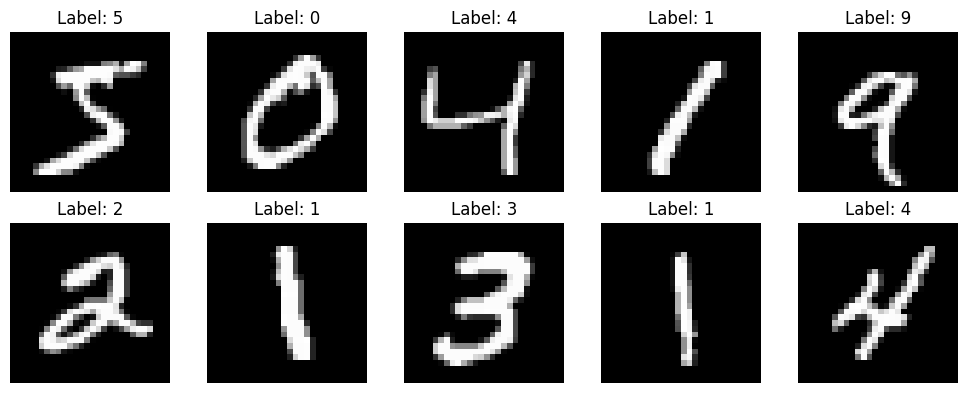

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    image, label = train_dataset[i]
    ax.imshow(image.squeeze(), cmap='gray')
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('../data/01_sample_digits.png')
plt.show()

In [4]:
class DigitNet(nn.Module):
    def __init__(self):
        super(DigitNet, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),           # [1,28,28] → [784]
            nn.Linear(784, 128),    # 784 inputs → 128 neurons
            nn.ReLU(),              # activation function
            nn.Linear(128, 64),     # 128 → 64 neurons
            nn.ReLU(),
            nn.Linear(64, 10)       # 64 → 10 outputs (one per digit)
        )
    
    def forward(self, x):
        return self.network(x)

model = DigitNet()
print(model)

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")

DigitNet(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)

Total trainable parameters: 109,386


In [5]:
criterion = nn.CrossEntropyLoss()   # loss function for multiclass
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        optimizer.zero_grad()           # clear previous gradients
        outputs = model(images)         # forward pass
        loss = criterion(outputs, labels)  # compute loss
        loss.backward()                 # backpropagation
        optimizer.step()               # update weights
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss/len(loader), correct/len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss/len(loader), correct/len(loader.dataset)

In [6]:
epochs = 5
print(f"{'Epoch':<8} {'Train Loss':<14} {'Train Acc':<14} {'Test Acc':<10}")
print("-" * 46)

for epoch in range(1, epochs+1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion)
    print(f"{epoch:<8} {train_loss:<14.4f} {train_acc:<14.4f} {test_acc:<10.4f}")

Epoch    Train Loss     Train Acc      Test Acc  
----------------------------------------------
1        0.2745         0.9190         0.9534    
2        0.1114         0.9660         0.9688    
3        0.0777         0.9761         0.9733    
4        0.0611         0.9804         0.9708    
5        0.0474         0.9848         0.9768    


In [7]:
class DigitNet(nn.Module):
    def __init__(self):
        super(DigitNet, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),           # [1,28,28] → [784]
            nn.Linear(784, 128),    # 784 inputs → 128 neurons
            nn.ReLU(),   
            nn.Linear(128, 10)       # 128 → 10 outputs (one per digit)
        )
    
    def forward(self, x):
        return self.network(x)

model = DigitNet()
print(model)

# Count total parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")

DigitNet(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total trainable parameters: 101,770


In [8]:
criterion = nn.CrossEntropyLoss()   # loss function for multiclass
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        optimizer.zero_grad()           # clear previous gradients
        outputs = model(images)         # forward pass
        loss = criterion(outputs, labels)  # compute loss
        loss.backward()                 # backpropagation
        optimizer.step()               # update weights
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss/len(loader), correct/len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss/len(loader), correct/len(loader.dataset)

In [9]:
epochs = 5
print(f"{'Epoch':<8} {'Train Loss':<14} {'Train Acc':<14} {'Test Acc':<10}")
print("-" * 46)

for epoch in range(1, epochs+1):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion)
    print(f"{epoch:<8} {train_loss:<14.4f} {train_acc:<14.4f} {test_acc:<10.4f}")

Epoch    Train Loss     Train Acc      Test Acc  
----------------------------------------------
1        0.2615         0.9249         0.9625    
2        0.1146         0.9653         0.9692    
3        0.0803         0.9752         0.9746    
4        0.0599         0.9809         0.9758    
5        0.0465         0.9850         0.9788    


In [10]:
class DigitCNN(nn.Module):
    def __init__(self):
        super(DigitCNN, self).__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),        # conv layer 1
            nn.ReLU(),
            nn.MaxPool2d(2),     # pool 1
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),        # conv layer 2
            nn.ReLU(),
            nn.MaxPool2d(2),     # pool 2
            nn.Flatten(),   
            nn.Linear(1600, 128),   # classifier     
            nn.ReLU(),
            nn.Linear(128, 10)    # output
        )
    
    def forward(self, x):
        return self.network(x)
    

cnn_model = DigitCNN()
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.001)

print(cnn_model)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"\nTotal trainable parameters: {total_params:,}")

epochs = 5
print(f"{'Epoch':<8} {'Train Loss':<14} {'Train Acc':<14} {'Test Acc':<10}")
print("-" * 46)

for epoch in range(1, epochs+1):
    train_loss, train_acc = train_epoch(cnn_model, train_loader, cnn_optimizer, criterion)
    test_loss, test_acc = evaluate(cnn_model, test_loader, criterion)
    print(f"{epoch:<8} {train_loss:<14.4f} {train_acc:<14.4f} {test_acc:<10.4f}")

DigitCNN(
  (network): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=1600, out_features=128, bias=True)
    (8): ReLU()
    (9): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total trainable parameters: 225,034
Epoch    Train Loss     Train Acc      Test Acc  
----------------------------------------------
1        0.1411         0.9576         0.9855    
2        0.0449         0.9862         0.9883    
3        0.0309         0.9903         0.9897    
4        0.0230         0.9925         0.9890    
5        0.0177         0.9940         0.9926    


In [11]:
import torch
import os

os.makedirs('../models', exist_ok=True)
torch.save(cnn_model.state_dict(), '../models/digit_cnn.pth')
print("Model saved.")

Model saved.
